In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision import models
import time
import numpy as np
import struct
from torch.utils.data import Dataset, DataLoader
import matplotlib
import matplotlib.pyplot as plt  # This is the correct way to import pyplot

In [2]:
# Définir une classe pour charger MNIST en utilisant les fichiers IDX
class MNISTDataset(Dataset):
    def __init__(self, image_file, label_file, transform=None):
        self.images = self._read_images(image_file)
        self.labels = self._read_labels(label_file)
        self.transform = transform

    def _read_images(self, file_path):
        with open(file_path, 'rb') as f:
            _, num, rows, cols = struct.unpack(">IIII", f.read(16))
            images = np.fromfile(f, dtype=np.uint8).reshape(num, 1, rows, cols)
            return images.astype(np.float32) / 255.0  # Normalisation

    def _read_labels(self, file_path):
        with open(file_path, 'rb') as f:
            _, num = struct.unpack(">II", f.read(8))
            labels = np.fromfile(f, dtype=np.uint8)
            return labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx]
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return torch.tensor(img, dtype=torch.float32), torch.tensor(label, dtype=torch.long)

In [3]:
# Chemins vers tes fichiers
train_images_path = "train-images.idx3-ubyte"
train_labels_path = "train-labels.idx1-ubyte"
test_images_path = "t10k-images.idx3-ubyte"
test_labels_path = "t10k-labels.idx1-ubyte"

In [4]:
# Préparer les datasets
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = MNISTDataset(train_images_path, train_labels_path, transform=transform)
test_dataset = MNISTDataset(test_images_path, test_labels_path, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [5]:
print(f"the Trainnig dataset size: {len(train_dataset)} examples")
print(f"Image shape: {train_dataset.images[0].shape}")
print(f"First 10 labels: {train_dataset.labels[:10]}")

# Check if there are any NaN values
print(f"NaN values in images: {np.isnan(train_dataset.images).any()}")

the Trainnig dataset size: 60000 examples
Image shape: (1, 28, 28)
First 10 labels: [5 0 4 1 9 2 1 3 1 4]
NaN values in images: False


In [6]:
# Visualize some examples
def visualize_examples(dataset, num_examples=5):
    plt.figure(figsize=(15, 8))
    for i in range(num_examples):
        plt.subplot(2, 5, i+1)
        # Images are already normalized and have shape (1, 28, 28)
        plt.imshow(dataset.images[i][0], cmap='gray')
        plt.title(f"Label: {dataset.labels[i]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

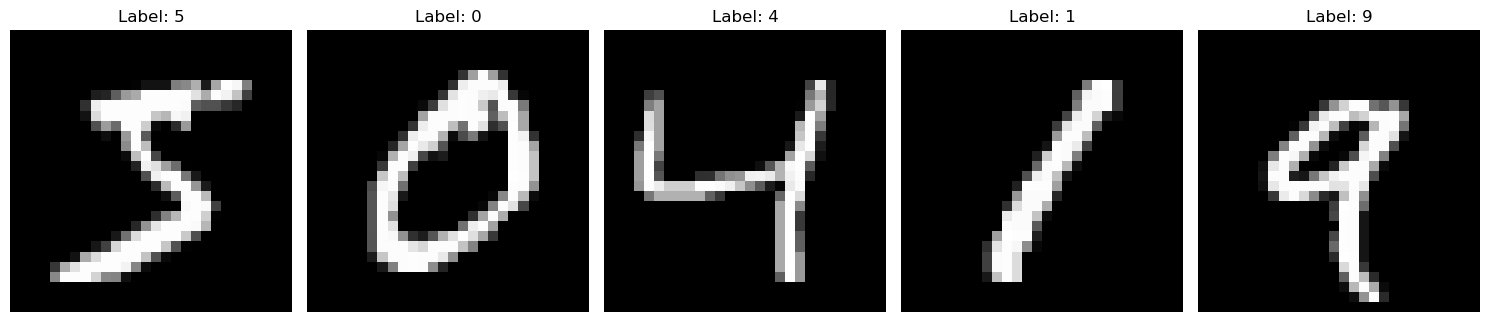

In [7]:
visualize_examples(train_dataset)

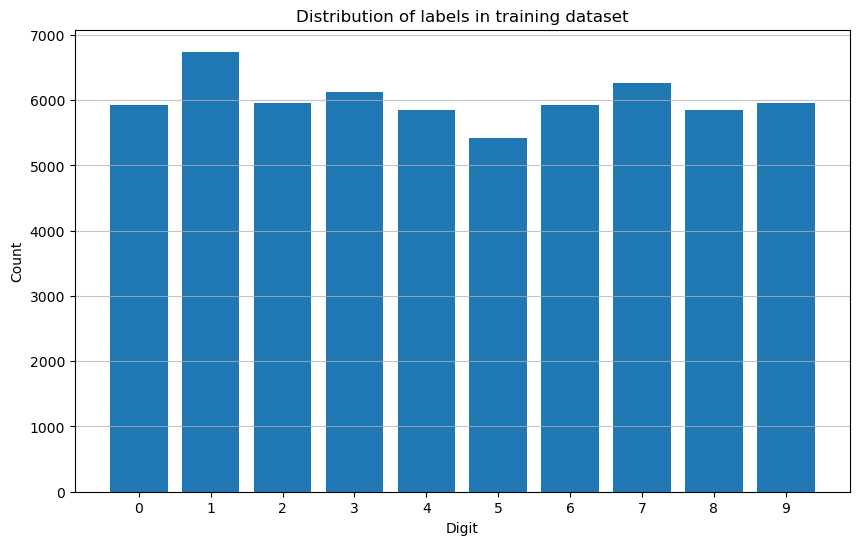

In [10]:
# Visualize distribution of labels
def visualize_label_distribution(dataset, name):
    labels = dataset.labels
    unique_labels, counts = np.unique(labels, return_counts=True)
    
    plt.figure(figsize=(10, 6))
    plt.bar(unique_labels, counts)
    plt.xlabel('Digit')
    plt.ylabel('Count')
    plt.title(f'Distribution of labels in {name} dataset')
    plt.xticks(unique_labels)
    plt.grid(axis='y', alpha=0.75)
    plt.show()
visualize_label_distribution(train_dataset, "training")

In [11]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.shape[0], -1)  # Flatten
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Initialisation du modèle
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_cnn = CNN().to(device)

# Définition de la fonction de perte et de l'optimiseur
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_cnn.parameters(), lr=0.001)


In [12]:
def train_model(model, train_loader, criterion, optimizer, epochs=5):
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for images, labels in train_loader:
            # Debug the shape
            #print(f"Original batch shape: {images.shape}")
            
            # Fix the shape - permute the dimensions to get [batch_size, channels, height, width]
            if images.shape[1] != 1:  # If channel dimension is not 1
                # This assumes your current shape is [batch_size, height, channels, width]
                images = images.permute(0, 2, 1, 3)
                #print(f"Corrected batch shape: {images.shape}")
            
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"Epoch {epoch+1}, Loss: {running_loss / len(train_loader)}")

In [13]:
train_model(model_cnn, train_loader, criterion, optimizer, epochs=5)

/tmp/ipykernel_5235/2664636854.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(img, dtype=torch.float32), torch.tensor(label, dtype=torch.long)


Epoch 1, Loss: 0.18588300828667068
Epoch 2, Loss: 0.05246607088488835
Epoch 3, Loss: 0.03665001867883859
Epoch 4, Loss: 0.02678993542628762
Epoch 5, Loss: 0.021439198671464946


In [20]:
import torchvision.models as models

# Charger Faster R-CNN pré-entraîné
model_frcnn = models.detection.fasterrcnn_resnet50_fpn(pretrained=True)

# Modifier la dernière couche pour MNIST (10 classes)
in_features = model_frcnn.roi_heads.box_predictor.cls_score.in_features
model_frcnn.roi_heads.box_predictor = models.detection.faster_rcnn.FastRCNNPredictor(in_features, 10)

model_frcnn = model_frcnn.to(device)
optimizer_frcnn = optim.Adam(model_frcnn.parameters(), lr=0.001)


In [38]:
def train_frcnn(model, train_loader, optimizer, epochs=5, accumulation_steps=4):
    model.train()
    device = next(model.parameters()).device  # Get the device from the model
    
    for epoch in range(epochs):
        running_loss = 0.0
        optimizer.zero_grad()  # Zero gradients at the beginning of each epoch
        
        for i, (images, labels) in enumerate(train_loader):
            # Convert your current data format to what Faster R-CNN expects
            images_list = []
            targets_list = []
            
            # For each image in the batch
            for j in range(images.shape[0]):
                # Handle different possible shapes
                if len(images.shape) == 4:  # [batch, channels, height, width]
                    if images.shape[1] == 1:  # Grayscale image [1, H, W]
                        img = images[j].repeat(3, 1, 1)  # Convert to 3 channels
                    else:
                        img = images[j]  # Already proper format
                elif len(images.shape) == 3:  # [batch, height, width] (no channel dimension)
                    img = images[j].unsqueeze(0).repeat(3, 1, 1)  # Add channel and repeat
                elif len(images.shape) == 2:  # [batch, flattened_pixels]
                    # Assume MNIST 28x28 flattened to 784
                    img = images[j].view(28, 28).unsqueeze(0).repeat(3, 1, 1)
                
                img = img.to(device)
                label = labels[j].item()  # Get the class index
                
                # Create a dummy bounding box covering the whole image
                h, w = img.shape[1], img.shape[2]
                dummy_box = torch.tensor([[0, 0, w-1, h-1]], dtype=torch.float32).to(device)
                
                # Create target dict with the format FRCNN expects
                target = {
                    'boxes': dummy_box,
                    'labels': torch.tensor([label + 1], dtype=torch.int64).to(device)  # +1 because 0 is background
                }
                
                images_list.append(img)
                targets_list.append(target)
            
            try:
                # Forward pass with proper format
                loss_dict = model(images_list, targets_list)
                
                # Calculate total loss
                losses = sum(loss for loss in loss_dict.values())
                
                # Normalize the loss to account for accumulation
                losses = losses / accumulation_steps
                
                # Backward pass
                losses.backward()
                
                # Update weights every accumulation_steps batches or at the end of an epoch
                if (i + 1) % accumulation_steps == 0:
                    optimizer.step()
                    optimizer.zero_grad()
                
                running_loss += losses.item() * accumulation_steps
                
            except RuntimeError as e:
                if 'out of memory' in str(e):
                    print('| WARNING: ran out of memory, skipping batch')
                    if hasattr(torch.cuda, 'empty_cache'):
                        torch.cuda.empty_cache()
                    optimizer.zero_grad()  # Clear any partial gradients
                else:
                    raise e
        
        # Don't forget to update parameters for the last batch if it's not divisible by accumulation_steps
        if (i + 1) % accumulation_steps != 0:
            optimizer.step()
            optimizer.zero_grad()
            
        print(f"Epoch {epoch+1}, Loss: {running_loss / len(train_loader)}")

In [ ]:
# Train with your existing train_loader
train_frcnn(model_frcnn, train_loader, optimizer_frcnn, epochs=5, accumulation_steps=4)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score
import time
import torch

def evaluate_model(model, test_loader, device):
    model.eval()
    y_true, y_pred = [], []
    start_time = time.time()
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            
            # Ensure images have the correct shape: [batch_size, channels, height, width]
            if images.ndimension() == 4:
                # If the image has 3 channels (RGB), no need to change
                # If it's 1 channel (grayscale), ensure the shape is (batch_size, 1, height, width)
                if images.shape[1] != 1:  # Not grayscale
                    images = images.permute(0, 3, 1, 2)  # Convert to (batch_size, channels, height, width)
                else:
                    # Ensure grayscale images have the correct shape
                    images = images.unsqueeze(1)  # (batch_size, 1, height, width) for grayscale

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
    
    end_time = time.time()
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="weighted")
    return acc, f1, end_time - start_time

# Example Usage
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cnn_acc, cnn_f1, cnn_time = evaluate_model(model_cnn, test_loader, device)
print(f"CNN - Accuracy: {cnn_acc:.4f}, F1 Score: {cnn_f1:.4f}, Time: {cnn_time:.2f}s")
